In [334]:

from sklearn.base import ClassifierMixin, BaseEstimator
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics.pairwise import euclidean_distances


from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_checkerboard

import warnings
import numpy as np

import matplotlib.pyplot as plt

X_train, y_train = make_blobs(n_samples=200_000, random_state=0, cluster_std=1, centers=2500, n_features=2500)

X_test, y_test = make_blobs(n_samples=100_00, random_state=0, cluster_std=1, centers=50, n_features=150)


In [ ]:

class KMeans_self_implemented(BaseEstimator, ClassifierMixin):
    def __init__(self, n_clusters=3, init_method='kmeans++', max_iter=200):
        self.n_clusters = n_clusters
        self.init_method = init_method
        self.max_iter = max_iter
        self._n_features_in = None

    def _init_clusters(self, size):
        return np.random.randint(low=0, high=self.n_clusters, size=size)
    
    def _init_centroids(self, X):
        if self.init_method == 'random':
            print("Doing random initialisation of cluster centroids")
            init_vals = X[np.random.choice(X.shape[0], size=self.n_clusters, replace=False)]
        elif self.init_method == 'kmeans++':
            print("Doing kmeans++ initialisation of cluster centroids")
            # https://theory.stanford.edu/~sergei/papers/kMeansPP-soda.pdf
            centroids = [X[np.random.choice(X.shape[0], size=1, replace=False)]]
            n_clusters_picked = 1

            while n_clusters_picked < self.n_clusters:
                print(100*n_clusters_picked / self.n_clusters)
                distances_arr_fast = euclidean_distances(X, np.concatenate(centroids))**2
                minimum_dist_idx = np.argmin(distances_arr_fast, axis=1)

                X_shortest = distances_arr_fast[np.arange(minimum_dist_idx.shape[0]), minimum_dist_idx]
                sample_weight = (X_shortest) / np.sum(X_shortest)
                centroids.append(X[np.random.choice(X.shape[0], size=1, p=sample_weight)])
                n_clusters_picked += 1
            init_vals = np.concatenate(centroids, axis=0)

        return init_vals
    
    def _calculate_cluster_centroid(self, X,y):
        centroids = []

        for i in np.unique(y):
            X_gp = X[np.where(y == i)[0]]
            centroids.append(X_gp.mean(axis=0))

        return np.stack(centroids)
    
    def _predict_cluster(self, X, centroids):      
        distances_arr_fast = euclidean_distances(X, centroids)**2
        minimum_dist_idx = np.argmin(distances_arr_fast, axis=1)
        
        return minimum_dist_idx
    

    def _plot_clusters(self, X, y, centroids):
        cmap = plt.get_cmap("tab20")

        for i in np.unique(y):
            X_gp = X[np.where(y == i)[0]]    
            plt.scatter(X_gp[:,0], X_gp[:,1], c=cmap(i))
        
        for centroid in centroids:
            plt.scatter(centroid[0], centroid[1], c='black')
        plt.show()



    def fit(self, X):
        assert self.n_clusters <= X.shape[0], f"Number of clusters {self.n_clusters} must be less than number of data points {X.shape[0]}"
        if (self.n_clusters == X.shape[0]): warnings.warn(f"The same number of clusters {self.n_clusters} as data points are used {X.shape[0]}")

        y_prev = self._init_clusters(X.shape[0])
        centroids = self._init_centroids(X)

        y_new = self._predict_cluster(X, centroids)

        for i in range(self.max_iter):
            print(i, self.max_iter)
            if i == self.max_iter-1: warnings.warn(f"Reached max iterations={self.max_iter}, increase max_iter parameter")
            if (y_prev == y_new).all(): 
                print("stationary clusters, breaking")
                break

            y_prev = y_new
            centroids = self._calculate_cluster_centroid(X, y_new)
            y_new = self._predict_cluster(X, centroids)
            # self._plot_clusters(X, y_new, centroids)

            print(100*np.sum(y_prev == y_new).sum() / y_prev.shape[0])

        self.centroids = centroids
        self._n_features_in = X.shape[1]
        self._is_fitted = True
        
    
    def predict(self, X):
        check_is_fitted(self)
        assert X.shape[1] == self._n_features_in, f"Number of features in {self._n_features_in} must be the same as number of prediction features {X.shape[1]}"

        return self._predict_cluster(X, self.centroids)

    def __sklearn_is_fitted__(self):
        """
        Check fitted status and return a Boolean value.
        """
        return hasattr(self, "_is_fitted") and self._is_fitted

km_SI = KMeans_self_implemented(n_clusters=150, max_iter=300, init_method='kmeans++')

km_SI.fit(X_train)

#y_preds = km_SI.predict(X_test)


Doing kmeans++ initialisation of cluster centroids
0.6666666666666666
1.3333333333333333
2.0
2.6666666666666665
3.3333333333333335
4.0
4.666666666666667
5.333333333333333
6.0
6.666666666666667
7.333333333333333
8.0
8.666666666666666
9.333333333333334
10.0
10.666666666666666
11.333333333333334
12.0
12.666666666666666
13.333333333333334
14.0
14.666666666666666
15.333333333333334
16.0
16.666666666666668
17.333333333333332
18.0
18.666666666666668
19.333333333333332
20.0
20.666666666666668
21.333333333333332
22.0
22.666666666666668
23.333333333333332
24.0
24.666666666666668
25.333333333333332
26.0
26.666666666666668
27.333333333333332
28.0
28.666666666666668
29.333333333333332
30.0
30.666666666666668
31.333333333333332
32.0
32.666666666666664
33.333333333333336
34.0
34.666666666666664
35.333333333333336
36.0
36.666666666666664
37.333333333333336
38.0
38.666666666666664
39.333333333333336
40.0
40.666666666666664
41.333333333333336
42.0
42.666666666666664
43.333333333333336
44.0
44.6666666666

/var/folders/3h/hhvlktwj1rzfznpk5wz5w45w0000gn/T/ipykernel_72092/1760289471.py:6: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_gp[:,0], X_gp[:,1], c=cmap(i))


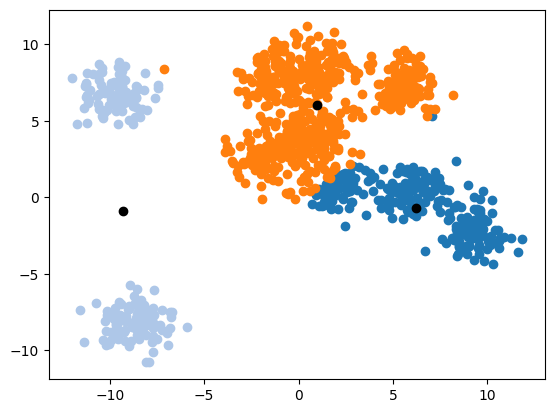

In [163]:

def plot_clusters(X, y, centroids):
    cmap = plt.get_cmap("tab20")

    for i in np.unique(y):
        X_gp = X[np.where(y == i)[0]]    
        plt.scatter(X_gp[:,0], X_gp[:,1], c=cmap(i))
    
    for centroid in centroids:
        plt.scatter(centroid[0], centroid[1], c='black')
    plt.show()

plot_clusters(X_test, y_preds, centroids=km_SI.centroids)


# def plot_clusters(X, y, cluster_centroids):
#     cmap = plt.get_cmap("tab20")

#     for i in np.unique(y):
#         X_gp = X[np.where(y == i)[0]]    
#         plt.scatter(X_gp[:,0], X_gp[:,1], c=cmap(i))
    
#     for i, (cluster_id, cluster_centroid) in enumerate(cluster_centroids.items()):
#         plt.scatter(cluster_centroid[0], cluster_centroid[1], c='black')
#     plt.show()

# plot_clusters(X_test, y_preds, cluster_centroids=km_SI.cluster_centroids)

In [200]:
km = KMeans(n_clusters=150, verbose=100, tol=0)
km.fit(X_train)



Initialization complete
Iteration 0, inertia 52676090.75761068.
Iteration 1, inertia 29760624.044718545.
Iteration 2, inertia 29733751.988241304.
Iteration 3, inertia 29718396.468294047.
Iteration 4, inertia 29708878.647075545.
Iteration 5, inertia 29702435.208856568.
Iteration 6, inertia 29697759.89839841.
Iteration 7, inertia 29694296.312850554.
Iteration 8, inertia 29691605.305253558.
Iteration 9, inertia 29689491.481631085.
Iteration 10, inertia 29687740.362262312.
Iteration 11, inertia 29686331.9859436.
Iteration 12, inertia 29685175.24402889.
Iteration 13, inertia 29684180.73850765.
Iteration 14, inertia 29683326.34293931.
Iteration 15, inertia 29682542.849505033.
Iteration 16, inertia 29681848.4073621.
Iteration 17, inertia 29681231.30216332.
Iteration 18, inertia 29680724.66813849.
Iteration 19, inertia 29680295.750507906.
Iteration 20, inertia 29679905.687250994.
Iteration 21, inertia 29679546.806740187.
Iteration 22, inertia 29679196.660845213.
Iteration 23, inertia 29678878.

,n_clusters,150
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0
,verbose,100
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [ ]:
%%timeit
# Current implementation - SLOW
distances = []
for centroid in centroids:
    distances.append(d(X_train, centroid)**2)

distances_arr = np.stack(distances)
y_new = np.argmin(distances_arr, axis=0)
X_shortest = np.concatenate([dist.reshape(-1,1) for dist in distances], axis=1)[np.arange(y_new.shape[0]), y_new]

sample_weight = (X_shortest) / np.sum(X_shortest)
distances_arr


2.46 s ± 36 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Faster euclidean distance calculation




In [ ]:
def d(P, cent):
    return np.sqrt(np.sum((P - cent)**2, axis=1))


In [27]:
%%timeit

distances = []
for centroid in centroids:
    distances.append(d(X_train, centroid)**2)



63.9 ms ± 1.63 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [28]:
%%timeit
euclidean_distances(X_train, centroids)**2

20.8 ms ± 1.91 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


**Provides about 20x improvement**
Improvement grows as n_features grows

# New implementation

In [134]:
centroids_arr = X_train[:1000]
centroids = centroids_arr.tolist()

In [135]:
%%timeit
# Current implementation - SLOW
distances = []
for centroid in centroids:
    distances.append(d(X_train, centroid)**2)

distances_arr = np.stack(distances)
y_new = np.argmin(distances_arr, axis=0)
X_shortest = np.concatenate([dist.reshape(-1,1) for dist in distances], axis=1)[np.arange(y_new.shape[0]), y_new]

sample_weight = (X_shortest) / np.sum(X_shortest)
distances_arr


2.46 s ± 36 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [136]:
%%timeit
# FAST implementation
distances_arr_fast = euclidean_distances(X_train, centroids_arr)**2
minimum_dist_idx = np.argmin(distances_arr_fast, axis=1)

X_shortest = distances_arr_fast[np.arange(y_new.shape[0]), y_new]

sample_weight = (X_shortest) / np.sum(X_shortest)



107 ms ± 4.16 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [341]:
np.full(10, -1, dtype=int)

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1])